# TT-16 — Decision Tree Regressor: Định giá cước chuyến xe (DỮ LIỆU THẬT)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor, export_text, plot_tree
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error
import joblib

np.random.seed(42)
%matplotlib inline

## Bước 1 — Đọc dữ liệu thật và lấy mẫu 200.000 dòng

In [2]:
REAL_DATA_PATH = "D:\TT_ML\TT-16-DecisionTreeRegressor_Linh\dataset\yellow_tripdata_2026-01.parquet"

df = pd.read_parquet(REAL_DATA_PATH)
print(f"Số dòng đọc được từ file gốc: {len(df):,}")

N_SAMPLE = 200_000
if len(df) > N_SAMPLE:
    df = df.sample(n=N_SAMPLE, random_state=42)
print(f"Số dòng sau lấy mẫu: {len(df):,}")
df.head()

<>:1: SyntaxWarning: invalid escape sequence '\T'
<>:1: SyntaxWarning: invalid escape sequence '\T'
C:\Users\lenovo\AppData\Local\Temp\ipykernel_18356\3302223245.py:1: SyntaxWarning: invalid escape sequence '\T'
  REAL_DATA_PATH = "D:\TT_ML\TT-16-DecisionTreeRegressor_Linh\dataset\yellow_tripdata_2026-01.parquet"


Số dòng đọc được từ file gốc: 3,724,889
Số dòng sau lấy mẫu: 200,000


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
1511419,1,2026-01-18 12:35:13,2026-01-18 12:46:05,1.0,3.90,1.0,N,68,238,1,17.00,3.25,0.5,2.50,0.00,1.0,24.25,2.5,0.0,0.75
3524883,2,2026-01-28 01:01:57,2026-01-28 01:34:45,NaN,13.95,NaN,NaN,69,61,0,49.13,0.00,0.5,0.00,7.46,1.0,58.09,NaN,NaN,0.00
652868,2,2026-01-09 10:35:27,2026-01-09 11:05:50,1.0,13.79,1.0,N,13,138,1,55.50,5.00,0.5,19.57,0.00,1.0,84.82,2.5,0.0,0.75
2115729,2,2026-01-24 22:26:51,2026-01-24 22:37:03,1.0,1.76,1.0,N,164,79,2,11.40,1.00,0.5,0.00,0.00,1.0,17.15,2.5,0.0,0.75
2645236,2,2026-01-01 01:59:23,2026-01-01 02:13:41,NaN,7.42,NaN,NaN,74,232,0,41.06,0.00,0.5,0.00,0.00,1.0,45.81,NaN,NaN,0.75


## Bước 2 — Làm sạch dữ liệu (4 bước bắt buộc)

1. Loại chuyến `fare_amount <= 0` (huỷ/hoàn tiền)
2. Loại chuyến `trip_distance <= 0` hoặc `> 100`
3. Loại chuyến `passenger_count == 0`
4. **Không** dùng `tip_amount`, `tolls_amount`, `total_amount` làm đặc trưng — đây là RÒ RỈ DỮ LIỆU vì các cột này chỉ biết SAU khi chuyến đi kết thúc, mà mình đang dự đoán `fare_amount` trước chuyến.

In [3]:
n0 = len(df)
df = df[df["fare_amount"] > 0]
n1 = len(df)
print(f"Loại vì fare_amount <= 0: {n0-n1:,} dòng")

df = df[(df["trip_distance"] > 0) & (df["trip_distance"] <= 100)]
n2 = len(df)
print(f"Loại vì trip_distance bất thường: {n1-n2:,} dòng")

df = df[df["passenger_count"] > 0]
n3 = len(df)
print(f"Loại vì passenger_count == 0: {n2-n3:,} dòng")

print(f"\nCòn lại: {n3:,} / {n0:,} dòng ({n3/n0*100:.1f}%)")

Loại vì fare_amount <= 0: 2,290 dòng
Loại vì trip_distance bất thường: 6,540 dòng
Loại vì passenger_count == 0: 54,088 dòng

Còn lại: 137,082 / 200,000 dòng (68.5%)


## Bước 3 — Tạo đặc trưng thời gian

In [4]:
df["hour"] = df["tpep_pickup_datetime"].dt.hour
df["dow"] = df["tpep_pickup_datetime"].dt.dayofweek
df["is_rush_hour"] = df["hour"].isin([7,8,9,16,17,18,19]).astype(int)

features = ["trip_distance", "passenger_count", "PULocationID", "DOLocationID", "hour", "dow", "is_rush_hour"]
X = df[features]
y = df["fare_amount"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train: {len(X_train):,} | Test: {len(X_test):,}")

Train: 109,665 | Test: 27,417


## Bước 4 — EDA: scatter quãng đường vs cước, giá trung bình theo giờ

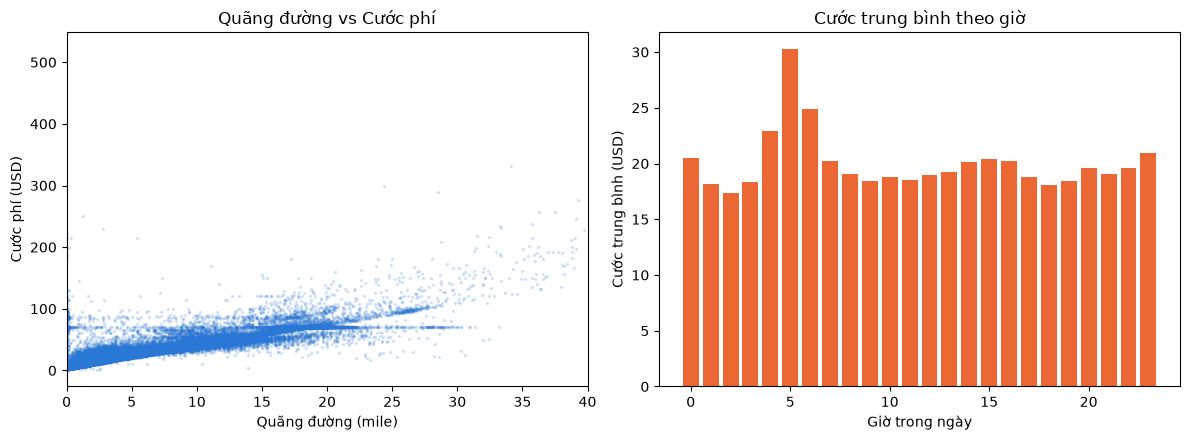

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].scatter(df["trip_distance"], df["fare_amount"], s=2, alpha=0.15, color="#2a78d6")
axes[0].set_xlabel("Quãng đường (mile)"); axes[0].set_ylabel("Cước phí (USD)")
axes[0].set_title("Quãng đường vs Cước phí"); axes[0].set_xlim(0, 40)

hourly_avg = df.groupby("hour")["fare_amount"].mean()
axes[1].bar(hourly_avg.index, hourly_avg.values, color="#eb6834")
axes[1].set_xlabel("Giờ trong ngày"); axes[1].set_ylabel("Cước trung bình (USD)")
axes[1].set_title("Cước trung bình theo giờ")
plt.tight_layout(); plt.show()

## Bước 5 — Baseline

So sánh với model "ngây thơ" nhất trước khi dùng Decision Tree, để biết Decision Tree
thực sự giá trị hơn bao nhiêu.

In [6]:
dummy = DummyRegressor(strategy="mean").fit(X_train, y_train)
mae_dummy = mean_absolute_error(y_test, dummy.predict(X_test))
print(f"DummyRegressor (mean)         MAE = {mae_dummy:.2f}")

manual_pred = 3.0 + 2.0 * X_test["trip_distance"]
mae_manual = mean_absolute_error(y_test, manual_pred)
print(f"Công thức thủ công (3+2*km)   MAE = {mae_manual:.2f}")

DummyRegressor (mean)         MAE = 12.05
Công thức thủ công (3+2*km)   MAE = 9.63


## Bước 6 — Cây không giới hạn độ sâu: chứng minh overfit

MAE trên tập train sẽ gần bằng 0 (cây "học thuộc" từng điểm dữ liệu), trong khi MAE
trên tập test cao hơn nhiều — đây là dấu hiệu kinh điển của overfitting.

In [7]:
tree_full = DecisionTreeRegressor(random_state=42)
tree_full.fit(X_train, y_train)

mae_train_full = mean_absolute_error(y_train, tree_full.predict(X_train))
mae_test_full = mean_absolute_error(y_test, tree_full.predict(X_test))

print(f"Số lá: {tree_full.get_n_leaves():,} | Số tầng: {tree_full.get_depth()}")
print(f"MAE train = {mae_train_full:.3f}")
print(f"MAE test  = {mae_test_full:.3f}  <-- cao hơn hẳn MAE train => OVERFIT")

Số lá: 90,316 | Số tầng: 41
MAE train = 0.010
MAE test  = 3.602  <-- cao hơn hẳn MAE train => OVERFIT


## Bước 7 — Quét max_depth từ 1 đến 20, tìm điểm tối ưu

Độ sâu có MAE test thấp nhất: 15 (MAE = 3.041)


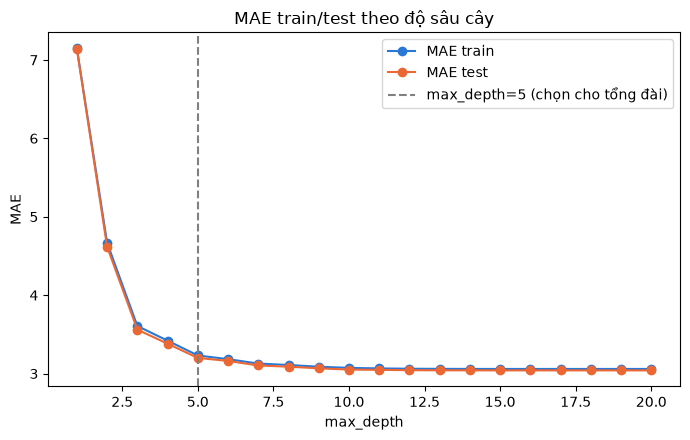

In [8]:
depths = list(range(1, 21))
train_maes, test_maes = [], []
for d in depths:
    t = DecisionTreeRegressor(max_depth=d, min_samples_leaf=500, random_state=42)
    t.fit(X_train, y_train)
    train_maes.append(mean_absolute_error(y_train, t.predict(X_train)))
    test_maes.append(mean_absolute_error(y_test, t.predict(X_test)))

best_depth = depths[int(np.argmin(test_maes))]
print(f"Độ sâu có MAE test thấp nhất: {best_depth} (MAE = {min(test_maes):.3f})")

plt.figure(figsize=(7,4.5))
plt.plot(depths, train_maes, marker="o", label="MAE train", color="#2a78d6")
plt.plot(depths, test_maes, marker="o", label="MAE test", color="#eb6834")
plt.axvline(5, color="gray", linestyle="--", label="max_depth=5 (chọn cho tổng đài)")
plt.xlabel("max_depth"); plt.ylabel("MAE"); plt.title("MAE train/test theo độ sâu cây")
plt.legend(); plt.tight_layout(); plt.show()

**Nhận xét:** Điểm tối ưu thống kê (MAE test thấp nhất) có thể rơi vào độ sâu khác,
nhưng đề bài chọn **max_depth=5** vì ưu tiên khả năng IN RA BẢNG TRA CỨU cho tổng đài
hơn là tối ưu tuyệt đối về độ chính xác. Đây là đánh đổi có chủ đích giữa chính xác và
khả năng vận hành thực tế.

## Bước 8 — Hàm dự đoán là hàm BẬC THANG (đặc điểm quan trọng nhất của cây hồi quy)

Khác với hồi quy tuyến tính cho ra đường thẳng/mượt, cây hồi quy chỉ có thể trả về
đúng số giá trị = số lá. Đây là giới hạn cơ bản cần hiểu rõ.

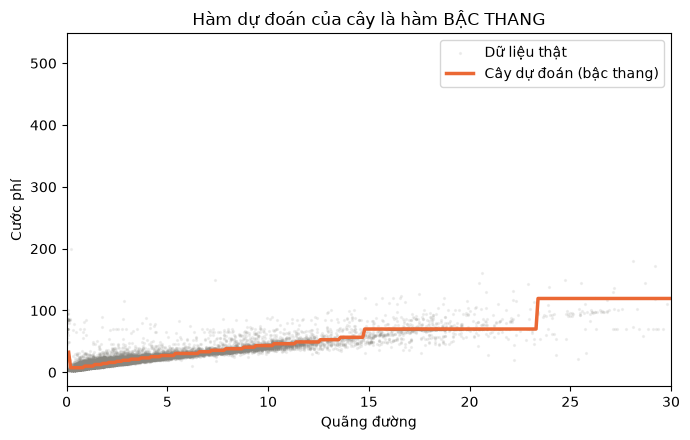

Số mức giá (lá) tối đa có thể trả ra: 27


In [9]:
tree5 = DecisionTreeRegressor(max_depth=5, min_samples_leaf=500,
                               criterion="squared_error", random_state=42)
tree5.fit(X_train, y_train)

dist_range = np.linspace(0.1, 30, 300)
sample_row = X_train.iloc[0].copy()
grid = pd.DataFrame([sample_row] * len(dist_range))
grid["trip_distance"] = dist_range
step_pred = tree5.predict(grid)

plt.figure(figsize=(7,4.5))
plt.scatter(X_test["trip_distance"], y_test, s=2, alpha=0.1, color="#888780", label="Dữ liệu thật")
plt.plot(dist_range, step_pred, color="#eb6834", linewidth=2.5, label="Cây dự đoán (bậc thang)")
plt.xlim(0, 30); plt.xlabel("Quãng đường"); plt.ylabel("Cước phí")
plt.title("Hàm dự đoán của cây là hàm BẬC THANG")
plt.legend(); plt.tight_layout(); plt.show()

print(f"Số mức giá (lá) tối đa có thể trả ra: {tree5.get_n_leaves()}")

## Bước 9 — Xuất cây dạng text và vẽ cây quyết định

In [10]:
print(export_text(tree5, feature_names=features))

|--- trip_distance <= 7.12
|   |--- trip_distance <= 2.42
|   |   |--- trip_distance <= 1.30
|   |   |   |--- trip_distance <= 0.15
|   |   |   |   |--- value: [32.39]
|   |   |   |--- trip_distance >  0.15
|   |   |   |   |--- trip_distance <= 0.86
|   |   |   |   |   |--- value: [7.45]
|   |   |   |   |--- trip_distance >  0.86
|   |   |   |   |   |--- value: [10.04]
|   |   |--- trip_distance >  1.30
|   |   |   |--- trip_distance <= 1.74
|   |   |   |   |--- hour <= 7.50
|   |   |   |   |   |--- value: [10.65]
|   |   |   |   |--- hour >  7.50
|   |   |   |   |   |--- value: [12.62]
|   |   |   |--- trip_distance >  1.74
|   |   |   |   |--- trip_distance <= 2.01
|   |   |   |   |   |--- value: [14.32]
|   |   |   |   |--- trip_distance >  2.01
|   |   |   |   |   |--- value: [15.94]
|   |--- trip_distance >  2.42
|   |   |--- trip_distance <= 4.17
|   |   |   |--- trip_distance <= 3.15
|   |   |   |   |--- trip_distance <= 2.75
|   |   |   |   |   |--- value: [17.74]
|   |   |   |

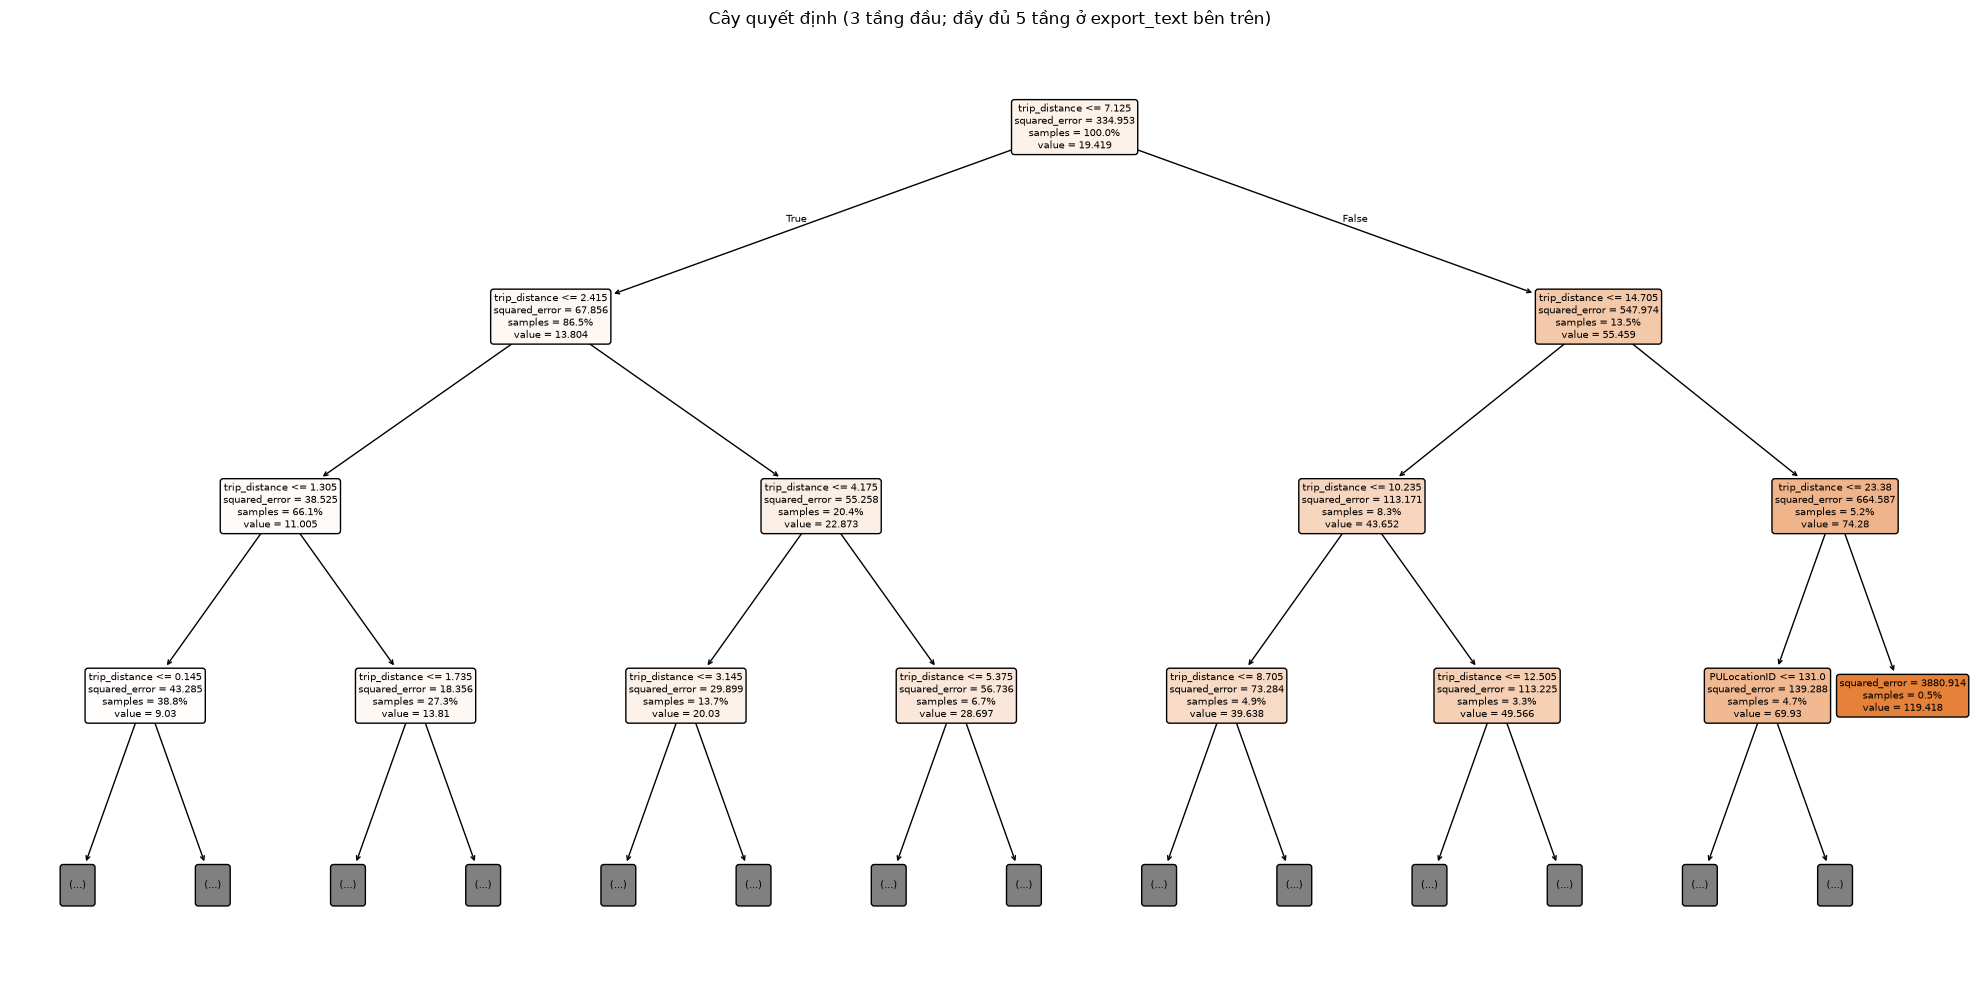

In [11]:
plt.figure(figsize=(20, 10))
plot_tree(tree5, feature_names=features, filled=True, rounded=True,
          fontsize=7, max_depth=3, proportion=True)
plt.title("Cây quyết định (3 tầng đầu; đầy đủ 5 tầng ở export_text bên trên)")
plt.tight_layout(); plt.show()

## Bước 10 — Chuyển cây thành BẢNG TRA CƯỚC (sản phẩm bàn giao)

Mỗi lá là một "luật" mà tổng đài viên có thể tra tay: dựa vào quãng đường và
giờ trong ngày, biết ngay mức giá đề xuất.

In [12]:
leaf_ids_train = tree5.apply(X_train)
tmp = X_train.copy()
tmp["leaf_id"] = leaf_ids_train
tmp["gia_du_doan"] = tree5.predict(X_train)

bang_tra_cuoc = (
    tmp.groupby("leaf_id")
    .agg(gia_de_xuat=("gia_du_doan", "mean"),
         so_chuyen_lam_can_cu=("gia_du_doan", "count"),
         km_min=("trip_distance", "min"),
         km_max=("trip_distance", "max"),
         ty_le_gio_cao_diem=("is_rush_hour", "mean"))
    .reset_index().sort_values("km_min")
)
bang_tra_cuoc["gia_de_xuat"] = bang_tra_cuoc["gia_de_xuat"].round(1)
bang_tra_cuoc["ty_le_gio_cao_diem"] = (bang_tra_cuoc["ty_le_gio_cao_diem"]*100).round(0)

bang_tra_cuoc.to_csv("../outputs/bang_tra_cuoc.csv", index=False, encoding="utf-8-sig")
print(f"Đã lưu {len(bang_tra_cuoc)} mức giá -> outputs/bang_tra_cuoc.csv")
bang_tra_cuoc

Đã lưu 27 mức giá -> outputs/bang_tra_cuoc.csv


,leaf_id,gia_de_xuat,so_chuyen_lam_can_cu,km_min,km_max,ty_le_gio_cao_diem
0,4,32.4,518,0.01,0.14,35.0
1,6,7.5,21073,0.15,0.85,40.0
2,7,10.0,20959,0.86,1.30,40.0
3,10,10.7,1394,1.31,1.73,27.0
4,11,12.6,13412,1.31,1.73,41.0
5,13,14.3,7366,1.74,2.01,39.0
6,14,15.9,7783,2.02,2.41,39.0
7,18,17.7,4730,2.42,2.75,38.0
8,19,19.4,4060,2.76,3.14,36.0
9,21,21.2,3474,3.15,3.61,35.0


## Bước 11 — Kiểm tra % chuyến đạt sai số trong ±15%

In [13]:
pred_test = tree5.predict(X_test)
mae5 = mean_absolute_error(y_test, pred_test)
mape5 = mean_absolute_percentage_error(y_test, pred_test) * 100
rmse5 = mean_squared_error(y_test, pred_test) ** 0.5

error_pct = np.abs(pred_test - y_test) / y_test
within_15 = (error_pct <= 0.15).mean() * 100

print(f"MAE  = {mae5:.2f}")
print(f"MAPE = {mape5:.2f}%")
print(f"RMSE = {rmse5:.2f}")
print(f"% chuyến sai số trong ±15%: {within_15:.1f}%")

MAE  = 3.20
MAPE = 20.23%
RMSE = 7.51
% chuyến sai số trong ±15%: 53.0%


## Bước 12 — So sánh với Random Forest (TT-17) và Linear Regression

Decision Tree (depth=5)  MAE = 3.20
Linear Regression        MAE = 3.40
Random Forest            MAE = 2.90


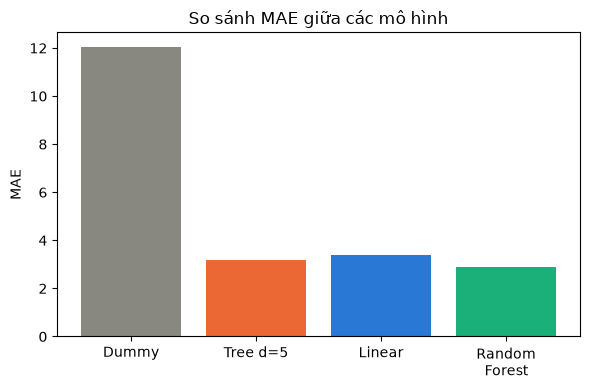

In [14]:
lin = LinearRegression().fit(X_train, y_train)
mae_lin = mean_absolute_error(y_test, lin.predict(X_test))

rf = RandomForestRegressor(n_estimators=200, max_depth=10, min_samples_leaf=200,
                            random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
mae_rf = mean_absolute_error(y_test, rf.predict(X_test))

print(f"Decision Tree (depth=5)  MAE = {mae5:.2f}")
print(f"Linear Regression        MAE = {mae_lin:.2f}")
print(f"Random Forest            MAE = {mae_rf:.2f}")

plt.figure(figsize=(6,4))
plt.bar(["Dummy","Tree d=5","Linear","Random\nForest"],
        [mae_dummy, mae5, mae_lin, mae_rf],
        color=["#888780","#eb6834","#2a78d6","#1baf7a"])
plt.ylabel("MAE"); plt.title("So sánh MAE giữa các mô hình")
plt.tight_layout(); plt.show()

## Lưu model

In [15]:
joblib.dump(tree5, "../models/tree_reg.joblib")
print("Đã lưu models/tree_reg.joblib")

Đã lưu models/tree_reg.joblib
